# 📌 Introduction to the Notebook: Mean / Median Imputation

This notebook provides a practical, hands-on exploration of handling missing numerical data using **mean and median imputation**. You will learn:

✅ Why missing data is a challenge in real-world datasets<br>
✅ How mean/median imputation works and when it is appropriate<br>
✅ The benefits and limitations of these simple imputation techniques<br>
✅ Practical coding examples using Python (pandas, scikit-learn)<br>
✅ How to validate the effect of imputation on the data distribution, using visual tools like histograms and KDE plots as well as summary statistics<br>

The notebook follows a structured approach:

1️⃣ Introduces a dataset with missing values<br>
2️⃣ Applies mean and median imputation step by step<br>
3️⃣ Compares the distributions before and after imputation<br>
4️⃣ Highlights best practices, including when and when *not* to use these techniques<br>

By the end of this notebook, you will have a solid understanding of how to quickly handle missing numerical values in simple scenarios, and what caveats to watch out for in a production-grade machine learning workflow.

---

📌 TIPS:

you typically handle/impute missing values only on training data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Import train_test_split to split data into training and test sets
from sklearn.model_selection import train_test_split

# Import SimpleImputer to handle missing data (e.g., replacing missing values with mean or median)
from sklearn.impute import SimpleImputer

# Import ColumnTransformer to apply different transformations to different columns
from sklearn.compose import ColumnTransformer

In [36]:
df = pd.read_csv('titanic_toy.csv') # truncated version of titanic dataset

In [37]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [39]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


📌 **Interpretation of the output**

- About **19.9%** of the `Age` values are missing.  
- About **5%** of the `Fare` values are missing.  
- `Family` has **no missing values** (0% missing).  
- `Survived` also has **no missing values** (0% missing).

In [40]:
# Create X by dropping the target column 'Survived' from the DataFrame.
# X will hold the features (inputs) used to predict.
X = df.drop(columns=['Survived'])

# Create y by selecting only the 'Survived' column from the DataFrame.
# y will hold the target (output) variable we want to predict.
y = df['Survived']

---

**In other words**:

✅ `X` = everything you’ll use as input features (like `Age`, `Fare`, `Family`)<br>
✅ `y` = the thing you want to predict (the `Survived` column)

---

In [41]:
# Split the data into training and testing sets
# X_train: features for training
# X_test: features for testing
# y_train: target labels for training
# y_test: target labels for testing

# test_size=0.2 means 20% of the data goes to testing, 80% to training
# random_state=2 fixes the random split so you get the same result every time you run it (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [42]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

---

Let’s interpret that:

✅ `X_train.shape` is `(712, 3)`

* means your **training** feature set has 712 rows (examples)
* and 3 columns (features: probably `Age`, `Fare`, `Family`)

✅ `X_test.shape` is `(179, 3)`

* means your **test** feature set has 179 rows
* and the same 3 columns

**In simple terms:**
👉 You are training your model on 712 passengers, and testing it on 179 passengers, using 3 features for each passenger.

---


In [43]:
print(X_train.isnull().mean())

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64


---

👉 **Interpretation of Output:**

* About **20.8%** of `Age` values are missing in your **training data**
* About **5%** of `Fare` values are missing in your **training data**
* `Family` has **0% missing values** in training

**Why check this on `X_train`?**

✅ Because when you build and fit a model, you typically handle/impute missing values **only on training data** — you want to know exactly what is missing there before applying any data cleaning steps.

---

In [44]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [45]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [46]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
662,47.0,NaN,0,47.0,47.0,14.4583,32.617597
657,32.0,15.5000,2,32.0,32.0,15.5000,15.500000
337,41.0,134.5000,0,41.0,41.0,134.5000,134.500000
867,31.0,50.4958,0,31.0,31.0,50.4958,50.495800
625,61.0,32.3208,0,61.0,61.0,32.3208,32.320800


In [47]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.2385256705547


---

👉 ***Interpretation of Output:***

---

✅ **Original Age variable variance: 204.35**

* This is the variance of `Age` **before** you filled in the missing values.
* Variance measures how spread out the ages are.

✅ **After median imputation: 161.99**<br>
✅ **After mean imputation: 161.81**<br>

* After replacing missing ages with either the median or the mean, the variance **went down**.
* Why? Because you replaced missing values with a **single repeated number** (mean or median), which reduces variability (less spread)

---

> ✅ **Why does variance decrease after imputation with mean or median?**
> Because you're replacing all missing values with a **single fixed number** (either the mean or the median), those new values are **not spread out** — they are **clustered** around that fixed value.
>
> Since **variance measures how far values are from the mean**, and the imputed values are now **equal to (or close to) the mean**, their contribution to variance is **very small or zero**.
>
> As a result, the **overall variance decreases**, because the dataset now contains more values with **low or no deviation from the mean**.

---

✅ **Original Fare variance: 2448.20**

* Again, this shows how spread out the `Fare` values are before imputation.

✅ **After median imputation: 2340.09**<br>
✅ **After mean imputation: 2324.24**<br>

* Variance goes down slightly after filling in missing `Fare` values with the mean or median, for the same reason: you insert repeated values, which slightly reduces spread.

---

**Key takeaway in beginner terms**:

* When you impute missing values with mean or median, you **reduce** the variance of that variable
* because you are adding the same repeated value in place of missing data
* so the data becomes a bit less spread out (less variable)
* Since in case of Age there were 20% missing values, the variance is bit high vs in Fare there were fewer missing values (5%) and hence lesser imputation and leading to lower variance

---

---

🤔 ***Why use Variance Over Standard Deviation?***

---

✅ **Variance** and **standard deviation** both measure how spread out data is.

* **Variance** is the *average of the squared distances* from the mean

  $$
  \text{Variance} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2
  $$

  so its units are **squared** (e.g., cm², dollars², years²)

* **Standard deviation** is simply the **square root of variance**, bringing it back to the same units as the data (e.g., cm, dollars, years)

---

**Why use variance instead of standard deviation?**

✅ In **technical or mathematical contexts** (like data science or machine learning), people often report variance because:

* variance is easier to work with in formulas (no square roots)
* it directly shows how much spread there is in squared terms, which is important for calculations (like loss functions in ML)
* it’s additive for independent variables, which standard deviation is *not*

✅ In **practical, interpretive contexts** (like reporting to a stakeholder), standard deviation is often clearer because it’s in the same units as the data.

---

**In your notebook, comparing variance before and after imputation makes sense** because:

* you want to see *relative changes* in spread
* you’re comparing apples to apples (same squared units)
* it’s easier to spot if variance dropped a lot

If you prefer, you can always take the square root to switch to standard deviation, but variance is mathematically more convenient to compare.

---


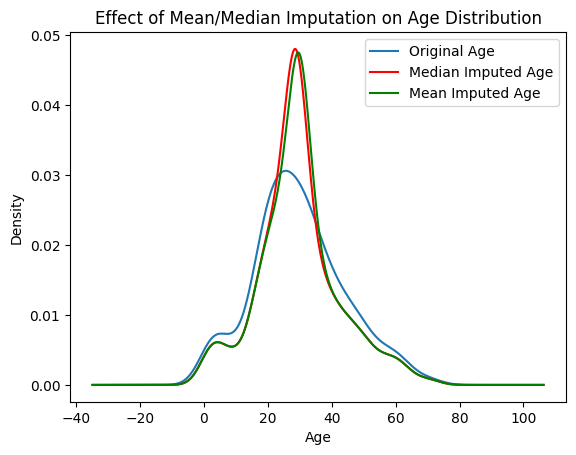

In [48]:
fig = plt.figure()
ax = fig.add_subplot(111)

# plot original Age
X_train['Age'].plot(kind='kde', ax=ax, label='Original Age')

# plot Age after median imputation
X_train['Age_median'].plot(kind='kde', ax=ax, color='red', label='Median Imputed Age')

# plot Age after mean imputation
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green', label='Mean Imputed Age')

# set the plot title
ax.set_title('Effect of Mean/Median Imputation on Age Distribution')

# add x-axis label
ax.set_xlabel('Age')

# add y-axis label
ax.set_ylabel('Density')

# add legend
ax.legend(loc='best')

---

👉 **How to interpret this plot**

✅ The **blue line** (original) shows how the true `Age` values are distributed (ignoring missing values). It represents what the ages looked like *before* you filled in the missing data.

✅ The **red line** (median imputed) shows what happens after you replace missing `Age` values with the median. Usually, you will see a **bump** near the median value, because all the missing entries have been filled with the same median, creating a local concentration there.

✅ The **green line** (mean imputed) is similar — it will usually show a **bump** at the mean value.

---

👉 **Overall,** these plots help you see that imputation affects your variable’s distribution:

* it introduces peaks (artificial spikes) at the imputed values
* it reduces the spread/variance (since many missing entries get the same replacement)
* and potentially alters the true distribution pattern

**Why important?**

When you choose an imputation strategy, it’s good to check these plots to make sure you are not distorting your data too much, which could hurt model performance later.

**Key takeway**

You should not see such drastic changes due to imputation

---

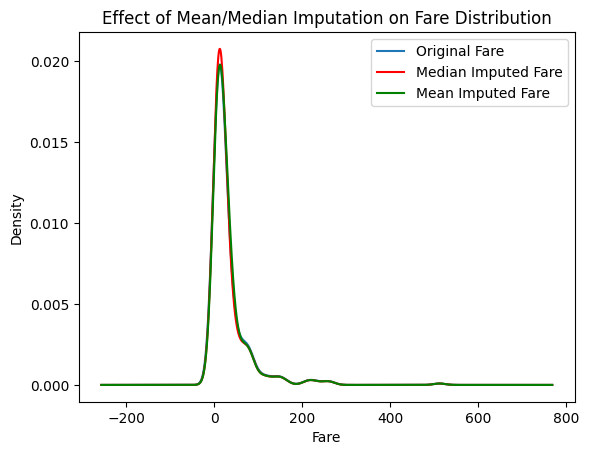

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

# plot the original Fare distribution
X_train['Fare'].plot(kind='kde', ax=ax, label='Original Fare')

# plot the Fare distribution after median imputation
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red', label='Median Imputed Fare')

# plot the Fare distribution after mean imputation
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green', label='Mean Imputed Fare')

# add a descriptive title
ax.set_title('Effect of Mean/Median Imputation on Fare Distribution')

# add x-axis label
ax.set_xlabel('Fare')

# add y-axis label
ax.set_ylabel('Density')

# add legend
ax.legend(loc='best')


---

👉 ***Interpretation of this plot***

---

✅ The **blue line** represents the original distribution of `Fare` (excluding missing values).<br>
✅ The **red line** shows what happens when you impute missing `Fare` values with the median — a spike will appear near the median fare value.<br>
✅ The **green line** shows what happens when you impute with the mean — another spike forms around the mean fare value.<br>

**What to notice?**

* Because `Fare` has some extreme values (outliers), the mean and median can be quite different, so the spikes in green/red may appear in different positions.
* Like with `Age`, these replacements slightly **reduce variance** and change the distribution shape, especially where many missing values are filled with the same number.

👉 **Why this is useful?**

* It helps you verify whether your chosen imputation method is distorting the distribution too much
* If the spike is too dominant, you might consider more advanced imputation strategies (like KNN or predictive modeling)

---

In [50]:
# print(X_train.cov())
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


---

✅ **What is covariance?**
Covariance measures how two variables change *together*:

* **positive covariance**: when one variable goes up, the other tends to go up
* **negative covariance**: when one goes up, the other tends to go down
* covariance is in *units of variable1 × variable2* (e.g., dollars·years), so it’s harder to interpret than correlation, but it still shows *direction* and *strength of joint variation*.

---

**Reading the matrix:**

👉 The **diagonal values** (top-left to bottom-right) are simply the **variances** of each variable.
For example:

* Age variance before imputation: 204.35
* Fare variance before imputation: 2448.19
* Family variance: 2.73

👉 The **off-diagonal values** show how much two variables vary together. For example:

* Age and Fare covariance: 70.71 (positive, meaning higher age tends to weakly associate with higher fare)
* Age and Family: -6.49 (negative, suggesting older passengers had slightly smaller families)

---

**Now look at the imputed columns:**

* Age with Age\_median: 204.35 (perfectly matched where non-missing, since imputed Age\_median only changes missing spots)
* Fare with Fare\_median: 2448.19 (again matching perfectly except for missing spots)
* Age\_median variance goes down to 161.99 (as seen earlier — variance reduced after imputation)
* Fare\_median variance goes down to 2340.09

You can also see:

* Covariances of Age\_median with other variables (like Family) slightly change from -6.49 to about -5.1
  → means the relationship weakened a bit after you replaced missing values with the median or mean
* Similarly, Fare’s relationship with Age drops from 70.7 to 57.9 or 55.6 after imputation
  → showing a slightly weaker joint variation because you replaced missing values with constant numbers

---

**Key takeaways in simple words:**

✅ The diagonal tells you **spread** of each variable (variance)<br>
✅ The off-diagonals tell you **relationships** between pairs of variables<br>
✅ After imputation, the variance goes down, and the covariance between variables also slightly weakens because you replaced missing values with fixed values, which removes some natural variability in how variables move together.<br>

👉 That’s why data scientists often visualize and review covariance (or correlation) after imputation — to be sure you didn’t destroy the relationships in the data.

---


In [51]:
# print(X_train.corr())
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


---

✅ **What is correlation?**

* Measures how strongly two variables move together
* **Ranges from -1 to +1**

  * +1 → perfect positive linear relationship
  * -1 → perfect negative linear relationship
  * 0 → no linear relationship
* Easier to interpret than covariance because it is dimensionless (no units).

---

### **Interpretation of these values:**

👉 **Diagonal elements** are always 1
(because each variable is perfectly correlated with itself).

---

**Some key observations:**

* `Age` and `Fare`: **0.092**
  → very weak positive relationship (almost no correlation)

* `Age` and `Family`: **-0.299**
  → moderate negative relationship (older people tend to have smaller family size on board)

* `Fare` and `Family`: **0.208**
  → weak positive correlation (higher fare might slightly be associated with larger families)

---

**Effect of imputation:**

* `Age` and `Age_median` or `Age_mean`: **1.000**
  → identical except at missing spots, so the correlation stays perfect

* `Fare` and `Fare_median` or `Fare_mean`: **1.000**
  → same reason, identical where non-missing

* `Age_median` and `Family`: went from **-0.299** to **-0.242**
  → after imputation, the relationship weakened slightly
  (because you replaced missing Age with a constant, which breaks the natural link between Age and Family size)

* `Fare_median` and `Family`: stayed roughly **0.21**
  → means Fare imputation did not distort its relationship with Family much

---

**Key takeaway in simple words**:

✅ Correlation helps you see *how strong* the variables are related, on a normalized scale<br>
✅ After mean/median imputation, correlations with other variables might **slightly weaken** because constant replacement reduces natural variation<br>
✅ But the overall pattern is mostly preserved, which is good<br>

---

**Why is this important?**

👉 In data cleaning, you want to **preserve relationships** between variables so that your model still sees realistic patterns in the data.<br>
👉 Checking `.corr()` before and after imputation is a great practice to confirm you did not destroy these relationships.<br>

---


<Axes: >

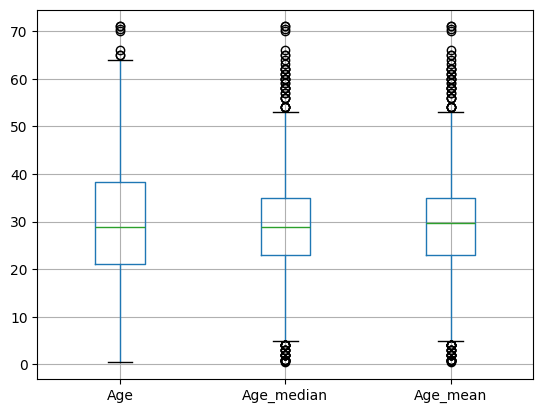

In [52]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

---

👉 ***Interpretation of the boxplot***

---

> This boxplot shows the distributions of the original `Age` column compared to the versions with **median-imputed** and **mean-imputed** missing values.

---

### 🔍 Interpretation:

1. **Original `Age` Column**:

   * Has natural variability and a **moderate number of outliers** (visible above and below whiskers).
   * Wider IQR (box width) reflecting original data spread.

2. **`Age_median` and `Age_mean` Columns**:

   * Both columns show:

     * **Narrower IQRs** (box is slightly compressed).
     * **Increased number of outliers**, especially near the top whisker.
   * This happens because missing values are filled with a **repeated central value**, so the variation (spread) shrinks.

3. **Why this is problematic** (as per instructor):

   * **Variance is reduced**, because many values now lie close to the center.
   * **Artificial outliers** are created due to compression of the IQR.
   * The **distribution is distorted** — this is not faithful to the original data.

---

### 💡 Instructor’s Advice:

> This kind of behavior is **not ideal**, especially if it leads to:

* More outliers
* Distorted shape
* Change in distribution spread

So, **always visualize with a boxplot** to confirm that imputation hasn’t introduced statistical bias or visual anomalies.

---

<Axes: >

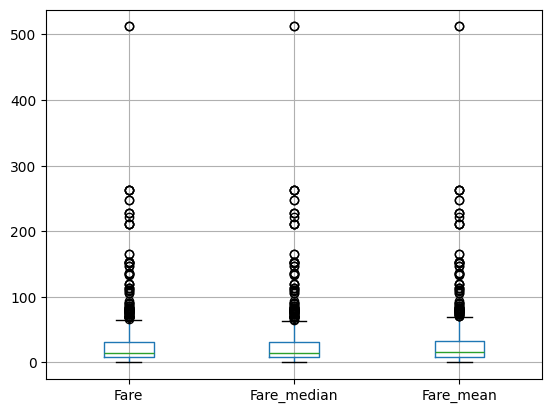

In [53]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

---

👉 ***Interpretation of the boxplot***

---

### ✅ Instructor’s Observations:

* **No significant change** in the distribution **before and after imputation**.
* **IQR (box width)** remains **almost identical** across `Fare`, `Fare_median`, and `Fare_mean`.
* The **number of outliers** and their placement is **unchanged**.
* **Variance (spread)** is **preserved**.
* **Correlations and interactions** with other features also **remained stable**.

---

## 📊 Visual Confirmation from the Boxplot

| Feature       | Observation                                                    |
| ------------- | -------------------------------------------------------------- |
| **Box shape** | Uniform and stable across all three versions.                  |
| **Outliers**  | Count, position, and spacing of outliers are nearly identical. |
| **Spread**    | No visible shrinkage or inflation in IQR or whiskers.          |

> This boxplot visually confirms that **mean and median imputation for the `Fare` column is safe and valid**.

---

## ✅ Instructor's Recommendation:

> For `Fare`, it’s safe to use **mean imputation** since:

* Distribution is not skewed
* No distortion occurs
* Variance and correlation with other features remain consistent

---

### 🔍 Instructor’s Advice:

You have **multiple imputation strategies** depending on the data type and problem:

| Strategy           | When to Use                                                                           |
| ------------------ | ------------------------------------------------------------------------------------- |
| `mean`, `median`   | For **numerical data**, especially if MCAR and low missingness                        |
| `most_frequent`    | For **categorical (technical)** data                                                  |
| `constant`         | When using an **arbitrary value** like -999 to indicate missing                       |
| `indicator` column | Used to explicitly flag where values were imputed (he plans to cover this separately) |

> He notes that these are **basic techniques** and will later show how to automate selection of the **best technique**.

---

---

## 🟩 🔧 Practical Advice for `Fare` vs. `Age` Imputation

### ✅ For `Fare`:

* **Mean imputation is acceptable** for `Fare`.
* Why? Because:

  * No significant change in distribution shape.
  * No major shift in variance.
  * No change in correlation or feature interaction.
* ✅ Safe to impute directly.
* Good candidate for **simple techniques** like `SimpleImputer(strategy='mean')`.

---

### ❌ For `Age`:

* Instructor **discourages mean/median imputation** for `Age`.
* Why?

  * Variance drops significantly.
  * Distribution shape changes — more outliers appear.
  * Correlation with other columns (e.g., `Fare`, `Family`) also changes.
  * This is called the **"Kuber effect"** (i.e., change in covariate relationships).
* ❌ Better to use more **sophisticated imputation techniques** (e.g., KNN, regression-based).

---

## 🧠 Summary of Best Practice Logic:

| Column | Advice       | Reason                                          |
| ------ | ------------ | ----------------------------------------------- |
| `Fare` | ✅ Use Mean   | Stable distribution, low impact on stats        |
| `Age`  | ❌ Avoid Mean | Changes variance, correlation, and distribution |

---

### Using Sklearn

In [54]:
from sklearn.model_selection import train_test_split

# Assume X contains your features (e.g., Age, Fare, etc.)
# and y contains the target variable (e.g., Survived)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,          # Feature matrix
    y,          # Target variable
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=2      # Seed for reproducibility (ensures same split every time)
)

# ➤ X_train: Training features (80% of rows from X)
# ➤ X_test:  Testing features (20% of rows from X)
# ➤ y_train: Training labels corresponding to X_train
# ➤ y_test:  Testing labels corresponding to X_test

In [55]:
X_train

,Age,Fare,Family
30,40.0,27.7208,0
10,4.0,16.7000,2
873,47.0,9.0000,0
182,9.0,31.3875,6
876,20.0,9.8458,0
...,...,...,...
534,30.0,8.6625,0
584,NaN,8.7125,0
493,71.0,49.5042,0
527,NaN,221.7792,0


In [56]:
from sklearn.impute import SimpleImputer

# ➤ imputer1: for median imputation — robust to outliers
# Recommended for features like 'Age' if distribution is skewed or has outliers
imputer1 = SimpleImputer(strategy='median')

# ➤ imputer2: for mean imputation — sensitive to outliers
# Recommended for features like 'Fare' if distribution is fairly normal
imputer2 = SimpleImputer(strategy='mean')

---

### ✅ Best Practices Based on Instructor’s Advice:

| Column | Imputer Strategy | Why                              |
| ------ | ---------------- | -------------------------------- |
| `Age`  | `median`         | More stable with skew & outliers |
| `Fare` | `mean`           | Safe due to stable distribution  |

---

In [57]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [58]:
# ColumnTransformer allows you to apply different transformations to different columns
trf = ColumnTransformer(
    transformers=[
        ('imputer1', imputer1, ['Age']),   # Apply median imputation to 'Age'
        ('imputer2', imputer2, ['Fare'])   # Apply mean imputation to 'Fare'
    ],
    remainder='passthrough'  # Keep all other columns as-is
)

In [59]:
trf.fit(X_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

---

### 🧠 What Happens Internally:

1. **Looks at X\_train's columns `'Age'` and `'Fare'`** as specified.
2. Applies:

   * `SimpleImputer(strategy='median')` to **'Age'**
     → calculates the **median** (e.g., `28.75`) and **stores** it.
   * `SimpleImputer(strategy='mean')` to **'Fare'**
     → calculates the **mean** (e.g., `32.60`) and **stores** it.
3. **Does not yet transform** or change the data — this is just the **learning phase**.

---

### 🔧 What Does It "Fit"?

| Transformer | Learns…           | Stored In                        |
| ----------- | ----------------- | -------------------------------- |
| `imputer1`  | Median of `'Age'` | `.statistics_` inside `imputer1` |
| `imputer2`  | Mean of `'Fare'`  | `.statistics_` inside `imputer2` |

---

### ✅ Why This Step Matters:

* Ensures **only training data is used** to calculate imputation values.
* Prevents **data leakage**.
* Sets up the pipeline for safe application to test or real-world data.

---

### 👉 Next Step:

To actually apply the transformations (i.e., fill in missing values), you call:

```python
X_train_transformed = trf.transform(X_train)
X_test_transformed = trf.transform(X_test)
```

---

---

### 🔍 Inline Explanation

```python
trf.fit(X_train)
```

* 🔧 `SimpleImputer(strategy='median')` is fitted **only on the `'Age'` column** from `X_train`.
* 🔧 `SimpleImputer(strategy='mean')` is fitted **only on the `'Fare'` column** from `X_train`.
* 🧠 The imputer learns:

  * The **median of `Age`** (ignoring missing values)
  * The **mean of `Fare`**
* ✅ This ensures **no data leakage** from `X_test`.

---

### ✅ Why this is important:

If you accidentally used `fit()` on **X\_test** or **the full dataset**, the imputer would learn from data it shouldn't have seen — violating the integrity of your model evaluation.

---

In [60]:
# This accesses the median value that SimpleImputer(strategy='median') computed for the 'Age' column during .fit()
trf.named_transformers_['imputer1'].statistics_

array([28.75])

---

### ✅ Interpretation:

* The **median age** calculated from the `X_train['Age']` column is **28.75**.
* This value will be used to **replace all missing Age values** in both `X_train` and `X_test`.

---

In [61]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

---

### ✅ Interpretation:

* The **mean of the `Fare` column** in your `X_train` data is **32.61759689**.
* This value will be used to **replace all missing `Fare` values** during `.transform(...)` calls.

---

## 🧠 Summary of Learned Values So Far:

| Column | Strategy Used | Learned Value | Source                                            |
| ------ | ------------- | ------------- | ------------------------------------------------- |
| `Age`  | `median`      | `28.75`       | `trf.named_transformers_['imputer1'].statistics_` |
| `Fare` | `mean`        | `32.61759689` | `trf.named_transformers_['imputer2'].statistics_` |

---

In [62]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

---

## 🔍 What Just Happened:

### ✅ On `X_train`:

* All missing values in the **`Age` column** were filled with `28.75` (the median).
* All missing values in the **`Fare` column** were filled with `32.61759689` (the mean).
* All **other columns** were **left untouched** due to `remainder='passthrough'`.

### ✅ On `X_test`:

* The **same fitted values** (`28.75` and `32.61759689`) were used — ensuring no data leakage.
* Transformation is consistent with the training set logic.

---

## ⚠️ Important Note:

After `.transform()`, your `X_train` and `X_test` are now **NumPy arrays**, not DataFrames.

So if you do:

```python
X_train.columns
```

⛔ You'll get an error: `'numpy.ndarray' object has no attribute 'columns'`.

---

## ✅ Optional Step: Convert Back to DataFrame

If you want to keep column names:

```python
# Manually specify column order after transformation
final_columns = ['Age', 'Fare'] + [col for col in X.columns if col not in ['Age', 'Fare']]

# Convert NumPy arrays back to DataFrames
X_train = pd.DataFrame(X_train, columns=final_columns, index=y_train.index)
X_test = pd.DataFrame(X_test, columns=final_columns, index=y_test.index)
```

Let me know if you'd like to visualize changes (e.g., using `.boxplot()`), or move on to model training.


---

## 🧠 Why do we use **training data’s** mean/median on both `X_train` and `X_test`?

### 📌 Short Answer:

Because **test data must not influence** what the model learns.
Using the test set’s statistics would lead to **data leakage**.

---

## 🔍 Detailed Explanation:

### ❌ Why we **don’t use X\_test’s own mean/median**:

If you impute `X_test` using its own statistics:

* You're allowing the model to "peek" into future or unseen data.
* This contaminates the integrity of the test set.
* It results in **overly optimistic performance metrics**, because your model indirectly had access to information it shouldn’t have.

### ✅ Why we use `X_train`’s statistics:

* The imputer is fitted (aka trained) **only on training data** using:

  ```python
  trf.fit(X_train)
  ```

* That means:

  * The **mean of Fare** (e.g., `32.61`)
  * The **median of Age** (e.g., `28.75`)
    — are **fixed from training data only**.

* When you apply:

  ```python
  trf.transform(X_test)
  ```

  → it uses **those same learned values** to impute missing values in `X_test`.

---

## 🧪 Analogy (Instructor-style 😄):

> Imagine you train a doctor using data from known patients.
> Now when that doctor sees a new patient (test case), you shouldn't let them "peek into" the average blood pressure values of all test patients.
> Instead, they should make decisions based on what they learned from the training phase.

---

## ✅ Summary

| Step                 | What Happens                             | Why                   |
| -------------------- | ---------------------------------------- | --------------------- |
| `fit(X_train)`       | Learns mean/median from training only    | Safe, no data leakage |
| `transform(X_train)` | Applies imputation using learned values  | OK                    |
| `transform(X_test)`  | Reuses training stats for missing values | ✅ Must do this!       |
| ❌ `fit(X_test)`      | Learns from test → leaks future info     | ❌ Invalid evaluation  |

---

Excellent follow-up — and you're absolutely right to think about this subtle point.

> ✅ Yes — **using the training data's mean or median to impute X\_test** **can** skew the distribution of `X_test`.

But here’s the key point:

---

## 🎯 The goal of test data is **not** to preserve its original distribution.

It is to **simulate how your model performs on truly unseen, real-world data**, where you:

* **don’t know the true distribution**, and
* **must rely only on what you learned during training.**

---

## 🔍 Breakdown:

### ✅ Why we *accept* distribution skew in `X_test`:

* It's the **correct trade-off** to **prevent data leakage**.
* In the real world, when a model is deployed:

  * You don’t have access to the full data at once.
  * You won’t be computing new means/medians on-the-fly.
  * You’ll use the values it learned during training (e.g., 28.75 for Age, 32.61 for Fare).
* So even if `X_test`’s imputed column is slightly **misaligned with its true distribution**, it **honestly reflects** how the model would behave in production.

---

## ❌ Why using `X_test`'s own stats would be misleading:

* It makes the test performance look artificially good.
* It assumes you know the test distribution — which defeats the purpose of having a **test set**.

---

## ✅ Best Practice Summary:

| Goal                                | Use Training Mean/Median? | Allow Skew? | Why                                |
| ----------------------------------- | ------------------------- | ----------- | ---------------------------------- |
| Evaluate true model performance     | ✅ Yes                     | ✅ Yes       | Simulates real-world inference     |
| Diagnose original test distribution | ❌ No                      | ❌ No        | Would leak test info into training |

---

## 👨‍🏫 Instructor’s Viewpoint (paraphrased):

> "You compute the mean/median from training data, and use that on test data — because your model should learn **only from training**, and test data should remain untouched."

---

In [64]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

In [65]:
# Reconstruct column names manually (order must match how ColumnTransformer outputs them)
final_columns = ['Age', 'Fare'] + [col for col in X.columns if col not in ['Age', 'Fare']]

# Convert back to DataFrame
import pandas as pd
X_train = pd.DataFrame(X_train, columns=final_columns, index=y_train.index)
X_test = pd.DataFrame(X_test, columns=final_columns, index=y_test.index)

In [66]:
X_train

,Age,Fare,Family
30,40.00,27.7208,0.0
10,4.00,16.7000,2.0
873,47.00,9.0000,0.0
182,9.00,31.3875,6.0
876,20.00,9.8458,0.0
...,...,...,...
534,30.00,8.6625,0.0
584,28.75,8.7125,0.0
493,71.00,49.5042,0.0
527,28.75,221.7792,0.0


### Takeaway

When to use Abitrary value imputation versus Mean / Median Imputation


| Situation                    | Technique                          | Reason                                                |
| ---------------------------- | ---------------------------------- | ----------------------------------------------------- |
| Missing At Random (MAR)      | **Mean / Median**                  | Safe default, maintains statistical properties        |
| Not Missing At Random (NMAR) | **Arbitrary value (e.g., -1, 99)** | Model learns from the fact that the value was missing |


Not Missing At Random (NMAR): Missing in chunks

---
